# Prudential Life Insurance Assessment — Ordinal Neural Network (Single Output Node)
## Dropout + Batch Normalization Experiments




In [11]:

# !pip install -q pandas numpy scikit-learn tensorflow

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import cohen_kappa_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [12]:
TRAIN_PATH = "train.csv"
assert os.path.exists(TRAIN_PATH), (
    "train.csv not found."
)

df = pd.read_csv(TRAIN_PATH)
print("Shape:", df.shape)
df.head()

Shape: (59381, 128)


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8


In [13]:

assert "Response" in df.columns, "Expected target column 'Response' not found in train.csv"

target = df["Response"].astype(int)
print("Response classes:", sorted(target.unique()))
print(target.value_counts().sort_index())

Response classes: [1, 2, 3, 4, 5, 6, 7, 8]
Response
1     6207
2     6552
3     1013
4     1428
5     5432
6    11233
7     8027
8    19489
Name: count, dtype: int64


In [14]:
X = df.drop(columns=["Response"])
y = df["Response"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (47504, 127) Val: (11877, 127)


In [15]:
# Identify numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ],
    remainder="drop"
)

# Fit on train only; transform train+val
X_train_proc = preprocess.fit_transform(X_train)
X_val_proc = preprocess.transform(X_val)

print("Processed train shape:", X_train_proc.shape)
print("Processed val shape:", X_val_proc.shape)

Numeric columns: 126
Categorical columns: 1
Processed train shape: (47504, 145)
Processed val shape: (11877, 145)


## Ordinal Target with a Single Output Node
Ordinal variable (1..8).


In [16]:
def round_and_clip(y_pred_cont: np.ndarray) -> np.ndarray:
    y_round = np.rint(y_pred_cont).astype(int)
    return np.clip(y_round, 1, 8)

def qwk_score(y_true: np.ndarray, y_pred_cont: np.ndarray) -> float:
    y_pred = round_and_clip(y_pred_cont)
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

# Quick sanity check on perfect predictions:
print("QWK perfect:", qwk_score(y_val.values, y_val.values.astype(float)))

QWK perfect: 1.0


## Define Model (MLP) + Loss



In [17]:
def build_model(input_dim: int, use_bn: bool = False, dropout_rate: float = 0.0) -> keras.Model:
    inputs = keras.Input(shape=(input_dim,))

    # Block 1
    x = layers.Dense(256)(inputs)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    # Block 2
    x = layers.Dense(128)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    # Block 3
    x = layers.Dense(64)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Single output node (linear) for ordinal regression
    outputs = layers.Dense(1, activation="linear")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber(delta=1.0)  # or "mse"
    )
    return model

model = build_model(input_dim=X_train_proc.shape[1], use_bn=False, dropout_rate=0.0)
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 145)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,593 (307.00 KB)

 Trainable params: 78,593 (307.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train Baseline + Evaluate (QWK)

In [18]:
def train_and_eval(config_name: str, use_bn: bool, dropout_rate: float, batch_size: int = 512, seed: int = 42):
    tf.keras.utils.set_random_seed(seed)
    model = build_model(input_dim=X_train_proc.shape[1], use_bn=use_bn, dropout_rate=dropout_rate)

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    history = model.fit(
        X_train_proc, y_train.values.astype(float),
        validation_data=(X_val_proc, y_val.values.astype(float)),
        epochs=200,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    val_pred_cont = model.predict(X_val_proc, verbose=0).ravel()
    val_loss = float(model.evaluate(X_val_proc, y_val.values.astype(float), verbose=0))
    val_qwk = float(qwk_score(y_val.values, val_pred_cont))

    out = {
        "config": config_name,
        "use_bn": use_bn,
        "dropout": dropout_rate,
        "val_loss": val_loss,
        "val_qwk": val_qwk,
        "epochs_trained": len(history.history["loss"])
    }
    return model, out

baseline_model, baseline_res = train_and_eval("baseline", use_bn=False, dropout_rate=0.0)
baseline_res

{'config': 'baseline',
 'use_bn': False,
 'dropout': 0.0,
 'val_loss': 0.9375327229499817,
 'val_qwk': 0.5941270629644242,
 'epochs_trained': 16}

## Experiment: Dropout vs BatchNorm (Ablation Study)

In [19]:
configs = [
    ("baseline", False, 0.0),
    ("dropout_0.3", False, 0.3),
    ("batchnorm", True, 0.0),
    ("batchnorm_dropout_0.3", True, 0.3),
]

models = {}
results = []

for name, use_bn, dr in configs:
    m, r = train_and_eval(name, use_bn=use_bn, dropout_rate=dr)
    models[name] = m
    results.append(r)

results_df = pd.DataFrame(results).sort_values(by="val_qwk", ascending=False)
results_df

,config,use_bn,dropout,val_loss,val_qwk,epochs_trained
3,batchnorm_dropout_0.3,True,0.3,0.887765,0.610032,42
0,baseline,False,0.0,0.937533,0.594127,16
2,batchnorm,True,0.0,0.972614,0.577975,16
1,dropout_0.3,False,0.3,1.182371,0.522887,11


## Visualizations (Data + Training + Results)


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,...,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.076923,2,1,1,0.641791,0.581818,...,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.076923,2,3,1,0.059701,0.600000,...,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.076923,2,3,1,0.029851,0.745455,...,0,0,0,0,0,0,0,0,0,8
3,7,1,D4,10,0.487179,2,3,1,0.164179,0.672727,...,0,0,0,0,0,0,0,0,0,8
4,8,1,D2,26,0.230769,2,3,1,0.417910,0.654545,...,0,0,0,0,0,0,0,0,0,8
5,10,1,D2,26,0.230769,3,1,1,0.507463,0.836364,...,0,0,0,0,0,0,0,0,0,8
6,11,1,A8,10,0.166194,2,3,1,0.373134,0.581818,...,0,0,0,0,0,0,0,0,0,8
7,14,1,D2,26,0.076923,2,3,1,0.611940,0.781818,...,0,0,0,0,0,0,0,0,0,1
8,15,1,D3,26,0.230769,2,3,1,0.522388,0.618182,...,0,0,0,0,0,0,0,0,0,8
9,16,1,E1,21,0.076923,2,3,1,0.552239,0.600000,...,0,0,0,0,0,0,0,0,0,1


Id                      int64
Product_Info_1          int64
Product_Info_2         object
Product_Info_3          int64
Product_Info_4        float64
                       ...   
Medical_Keyword_45      int64
Medical_Keyword_46      int64
Medical_Keyword_47      int64
Medical_Keyword_48      int64
Response                int64
Length: 128, dtype: object

,missing_count
Medical_History_10,58824
Medical_History_32,58274
Medical_History_24,55580
Medical_History_15,44596
Family_Hist_5,41811
Family_Hist_3,34241
Family_Hist_2,28656
Insurance_History_5,25396
Family_Hist_4,19184
Employment_Info_6,10854


Raw X_train shape       : (47504, 127)
Processed X_train shape : (47504, 145)
Raw X_val shape         : (11877, 127)
Processed X_val shape   : (11877, 145)


,config,use_bn,dropout,val_loss,val_qwk,epochs_trained
3,batchnorm_dropout_0.3,True,0.3,0.887765,0.610032,42
0,baseline,False,0.0,0.937533,0.594127,16
2,batchnorm,True,0.0,0.972614,0.577975,16
1,dropout_0.3,False,0.3,1.182371,0.522887,11


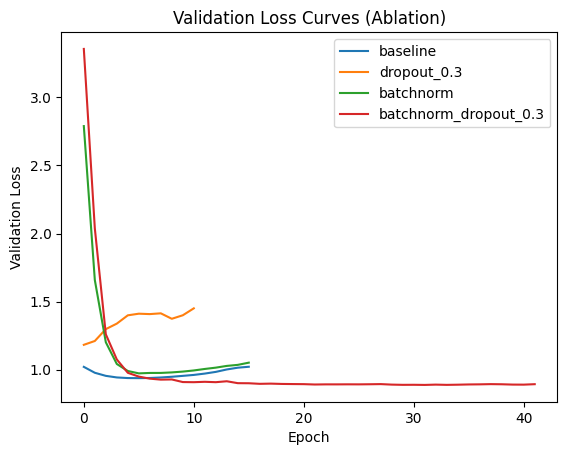

In [20]:
import matplotlib.pyplot as plt

# --- Raw data preview ---
display(df.head(10))

# --- Column dtypes ---
display(df.dtypes)

# --- Missing values (top 15) ---
missing_top = df.isnull().sum().sort_values(ascending=False).head(15)
display(missing_top.to_frame(name="missing_count"))

# --- Shape comparison: raw vs processed ---
print("Raw X_train shape       :", X_train.shape)
print("Processed X_train shape :", X_train_proc.shape)
print("Raw X_val shape         :", X_val.shape)
print("Processed X_val shape   :", X_val_proc.shape)

# --- Results table (highlight) ---
try:
    display(results_df.style.background_gradient(cmap="Blues"))
except Exception:
    display(results_df)

# --- Validation loss curves per configuration ---
def train_with_history(use_bn: bool, dropout_rate: float, batch_size: int = 512, seed: int = 42):
    tf.keras.utils.set_random_seed(seed)
    model = build_model(input_dim=X_train_proc.shape[1], use_bn=use_bn, dropout_rate=dropout_rate)

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    history = model.fit(
        X_train_proc, y_train.values.astype(float),
        validation_data=(X_val_proc, y_val.values.astype(float)),
        epochs=200,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    return history

histories = {}
for name, use_bn, dr in configs:
    histories[name] = train_with_history(use_bn=use_bn, dropout_rate=dr)

plt.figure()
for name, h in histories.items():
    plt.plot(h.history["val_loss"], label=name)
plt.title("Validation Loss Curves (Ablation)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()


In [21]:
best_config = results_df.iloc[0]
print("Best Model Configuration:")
print(best_config)

print("\nBest Validation QWK:", best_config["val_qwk"])
print("Best Validation Loss:", best_config["val_loss"])

best = results_df.iloc[0]

print(f"Best configuration: {best['config']}")
print(f"Dropout: {best['dropout']}")
print(f"BatchNorm: {best['use_bn']}")
print(f"Validation QWK: {best['val_qwk']:.4f}")
print(f"Validation Loss: {best['val_loss']:.4f}")

Best Model Configuration:
config            batchnorm_dropout_0.3
use_bn                             True
dropout                             0.3
val_loss                       0.887765
val_qwk                        0.610032
epochs_trained                       42
Name: 3, dtype: object

Best Validation QWK: 0.61003152938372
Best Validation Loss: 0.8877650499343872
Best configuration: batchnorm_dropout_0.3
Dropout: 0.3
BatchNorm: True
Validation QWK: 0.6100
Validation Loss: 0.8878
